#### Carnegie Mellon University - Tepper School of Business
#### 46-886 - Machine Learning Fundamentals
#### 22/23 - Mini 4 - Section M4 - Farahat
---

## Deliverable 4 
**Due Wednesday, April 19th at 2:59 a.m. Pittsburgh time**

**This is an individual assignment.**

*This deliverable consists of **one** problem of several parts. Each part requires you to code in **Python** and answer one or more questions. Save a copy of this notebook and provide your solution by inserting code or Markdown text cells as appropriate.*

*You will need to submit two files through Canvas: 1) a completed Jupyter notebook (extension .ipynb) with your code and answers to each question (this file); and 2) an html rendering of your completed Jupyter notebook.*

### Problem 1 - Predicting College Applications (100 points)

*This problem and accompanying dataset are taken from the textbook "An Introduction to Statistical Learning with Applications in R" (2nd edition) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani. Publisher: Springer, 2021*. 

In this problem, we will predict the number of applications received using the other variables in the <college.csv> data set.

First, import the dataset and create a **80-20** train-test split. Use **886** as the random seed throughout your code. 

Is you need to set a random state in any of the parts below, please use a fresh value of **886**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import statsmodels.api as sm
from graphviz import Source
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

In [4]:
from sklearn.preprocessing import PolynomialFeatures
#import warnings
#warnings.filterwarnings('ignore')

In [5]:
pd.options.display.max_columns = None

In [6]:
def OSR2(y_actual,y_pred,baseline):
    residuals = y_actual - y_pred
    SSR = np.sum((residuals)^2)
    SST = np.sum((y_actual - baseline)^2)
    R2 = 1 - SSR / SST
    return(R2) 

In [7]:
df = pd.read_csv("college.csv")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Private      777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F.Undergrad  777 non-null    int64  
 7   P.Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room.Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S.F.Ratio    777 non-null    float64
 15  perc.alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad.Rate    777 non-null    int64  
dtypes: float64(1), int64(16), object(1)
memory usage: 

In [9]:
y = df["Apps"]

In [10]:
X = df.drop("Apps", axis=1)

In [11]:
X = pd.get_dummies(X, drop_first=True)

In [12]:
X

,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Private_Yes
0,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,1
1,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,1
2,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,1
3,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,1
4,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40,0
773,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83,1
774,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49,1
775,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99,1


### Standardizing the Data

In [13]:
scaler = StandardScaler()
scaler.fit(X)

StandardScaler()

In [14]:
standardized_X = X.copy()
standardized_array = scaler.transform(standardized_X)

In [15]:
standardized_array = pd.DataFrame(scaler.transform(standardized_X))
standardized_X[:] = standardized_array

In [16]:
#standardized_X = standardized_X.drop(0, axis=1)

In [17]:
standardized_X

,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Private_Yes
0,-0.321205,-0.063509,-0.258583,-0.191827,-0.168116,-0.209207,-0.746356,-0.964905,-0.602312,1.270045,-0.163028,-0.115729,1.013776,-0.867574,-0.501910,-0.318252,0.612553
1,-0.038703,-0.288584,-0.655656,-1.353911,-0.209788,0.244307,0.457496,1.909208,1.215880,0.235515,-2.675646,-3.378176,-0.477704,-0.544572,0.166110,-0.551262,0.612553
2,-0.376318,-0.478121,-0.315307,-0.292878,-0.549565,-0.497090,0.201305,-0.554317,-0.905344,-0.259582,-1.204845,-0.931341,-0.300749,0.585935,-0.177290,-0.667767,0.612553
3,-0.681682,-0.692427,1.840231,1.677612,-0.658079,-0.520752,0.626633,0.996791,-0.602312,-0.688173,1.185206,1.175657,-1.615274,1.151188,1.792851,-0.376504,0.612553
4,-0.764555,-0.780735,-0.655656,-0.596031,-0.711924,0.009005,-0.716508,-0.216723,1.518912,0.235515,0.204672,-0.523535,-0.553542,-1.675079,0.241803,-2.939613,0.612553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,-0.205673,-0.255200,-1.336352,-1.505488,-0.126030,0.771435,-0.906289,-0.417455,-0.299280,-0.207855,-0.775861,-1.339146,1.746877,-0.706073,-0.994781,-1.483301,-1.632512
773,-0.087284,-0.091509,-0.201858,-0.444454,-0.175543,0.165435,0.268462,0.549707,0.306784,-0.133960,0.020822,-0.319632,-0.199632,0.666685,-0.090290,1.021555,0.612553
774,-0.042377,-0.091509,0.365389,0.262901,-0.187095,-0.453053,-0.880670,-0.143730,0.409815,-0.827095,-0.346878,-0.319632,0.078441,-0.221570,-0.256241,-0.959029,0.612553
775,0.177256,0.578333,3.825595,2.182866,0.312977,-0.507606,2.337894,1.963953,0.488603,1.144424,1.430339,1.107689,-2.095582,2.120194,5.887971,1.953595,0.612553


In [18]:
standardized_X.mean()

Accept         5.486816e-17
Enroll        -5.486816e-17
Top10perc     -4.115112e-17
Top25perc     -1.554598e-16
F.Undergrad    1.828939e-17
P.Undergrad    0.000000e+00
Outstate       1.554598e-16
Room.Board     3.474984e-16
Books         -1.760354e-16
Personal       4.572347e-17
PhD            4.572347e-17
Terminal      -4.115112e-16
S.F.Ratio     -6.401286e-17
perc.alumni    9.144694e-18
Expend         1.325981e-16
Grad.Rate      3.612154e-16
Private_Yes   -1.097363e-16
dtype: float64

In [19]:
standardized_X.std()

Accept         1.000644
Enroll         1.000644
Top10perc      1.000644
Top25perc      1.000644
F.Undergrad    1.000644
P.Undergrad    1.000644
Outstate       1.000644
Room.Board     1.000644
Books          1.000644
Personal       1.000644
PhD            1.000644
Terminal       1.000644
S.F.Ratio      1.000644
perc.alumni    1.000644
Expend         1.000644
Grad.Rate      1.000644
Private_Yes    1.000644
dtype: float64

In [20]:
X_train, X_test, y_train, y_test = train_test_split(standardized_X, y, test_size=0.2, random_state=886)

#### Part (a) [15pts]

Fit a linear model using least squares on the training set. You can use all the variables in the dataset (that is, do not worry about issues of multi-collinearity or variable selection). What is the in-sample and out-of-sample R-squared for this model?

In [21]:
lr_mod = LinearRegression()
lr_mod.fit(X_train, y_train)

LinearRegression()

In [22]:
print("Linear Regression train R2: ", lr_mod.score(X_train, y_train))
print("Linear Regression test R2: ", lr_mod.score(X_test, y_test))

Linear Regression train R2:  0.929411240661664
Linear Regression test R2:  0.9189721368390619


#### Part (b) [20pts]

Fit a ridge regression model on the training set, with λ chosen by (the default leave-on-out) cross-validation. Examine values of λ in the range [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1, 1e+2, 1e+3, 1e+4, 1e+5]. What is the best choice of λ in this range?

In [23]:
alphas=np.logspace(-5, 5, 11)


In [24]:
ridge_mod_cv = RidgeCV(alphas=alphas, store_cv_values=True)


In [25]:
ridge_mod_cv.fit(X_train, y_train)

RidgeCV(alphas=array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02,
       1.e+03, 1.e+04, 1.e+05]),
        store_cv_values=True)

In [26]:
ridge_mod_cv.alpha_

1e-05

#### ANSWER
The best choice for lambda in the given range is 0.1

In [27]:
alphas=np.logspace(-5, +10, 11, base=np.e)

In [28]:
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, solver="cholesky")
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)

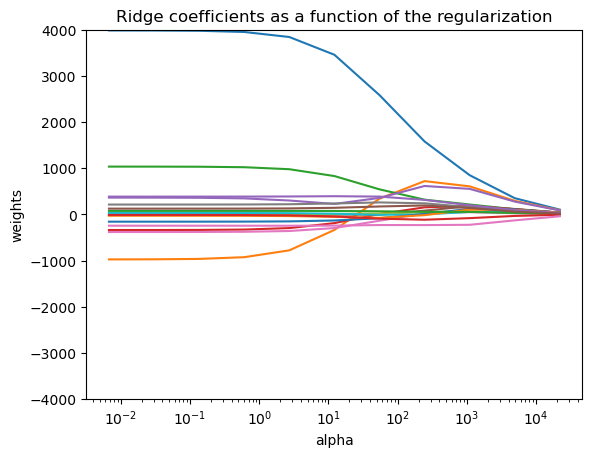

In [29]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.ylim(-4000, +4000)
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge coefficients as a function of the regularization")
#plt.axis("tight")
plt.show()

#### Part (c) [15pts]

What is the in-sample and out-of-sample R-squared for the Ridge regression model selected in Part (b)?

In [30]:
print("Ridge Regression with CV train R2: ", ridge_mod_cv.score(X_train, y_train))
print("Ridge Regression with CV test R2: ", ridge_mod_cv.score(X_test, y_test))

Ridge Regression with CV train R2:  0.9294112406616386
Ridge Regression with CV test R2:  0.9189721511580625


#### Part (d) [20pts]

Fit a LASSO regression model on the training set, with λ chosen by (the default leave-on-out) cross-validation. Examine values of λ in the range [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1, 1e+2, 1e+3, 1e+4, 1e+5]. What is the best choice of λ in this range?

In [31]:
alphas=np.logspace(-5, 5, 11)

In [32]:
lasso_mod_cv = LassoCV(alphas=alphas)

In [33]:
lasso_mod_cv.fit(X_train, y_train)

LassoCV(alphas=array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02,
       1.e+03, 1.e+04, 1.e+05]))

In [34]:
lasso_mod_cv.alpha_

1e-05

#### ANSWER
The best choice for lambda in the given range is 0.1

#### Part (e) [15pts]

What is the in-sample and out-of-sample R-squared for the LASSO model selected in Part (d)?

In [35]:
print("LASSO Regression with CV train R2: ", lasso_mod_cv.score(X_train, y_train))
print("LASSO Regression with CV test R2: ", lasso_mod_cv.score(X_test, y_test))

LASSO Regression with CV train R2:  0.9294112406616631
LASSO Regression with CV test R2:  0.9189721461302329


#### Part (f) [15pts]

What is the number of non-zero coefficient estimates for the LASSO model selected in Part (d)?

In [36]:
nonzero_coeff=0

for i in lasso_mod_cv.coef_:
    if i !=0:
        nonzero_coeff +=1
        
print("The number of non-zero coefficient estimates for the LASSO model is", nonzero_coeff)

The number of non-zero coefficient estimates for the LASSO model is 17


In [37]:
alphas=np.logspace(-5, +10, 11, base=np.e)

In [38]:
coefs = []
for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

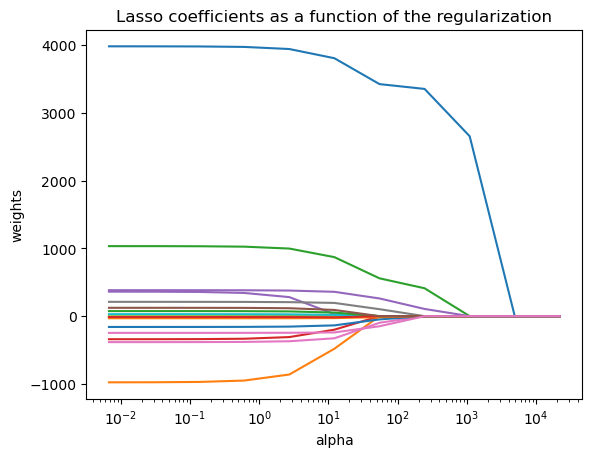

In [39]:
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.ylim(-4000, +4000)
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Lasso coefficients as a function of the regularization")
plt.axis("tight")
plt.show()

### END